In [1]:
import xarray as xr
import cfgrib
import airportsdata
import pandas as pd
import numpy as np
import os, sys
from datetime import date, timedelta

iata_airports = airportsdata.load('IATA')

In [26]:
import missingno as msno
import matplotlib.pyplot as plt

In [3]:
import timeit

In [45]:
os.getcwd()

'/Users/joaopedrocarvalho'

In [44]:
path = '/Users/joaopedrocarvalho/Documents/erdos_spring_2026/'

In [ ]:
alt_weather = 

In [12]:
weather = cfgrib.open_datasets(path+'weather-data/'+'2020_dec_weather.grib', engine = 'cfgrib')

/opt/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [23]:
print(weather)

[<xarray.Dataset> Size: 376MB
Dimensions:     (time: 63, step: 12, latitude: 105, longitude: 237)
Coordinates:
  * time        (time) datetime64[ns] 504B 2020-11-30T18:00:00 ... 2020-12-31...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 6kB 2020-11-30T19:00:00 ... 2021-...
  * latitude    (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude   (longitude) float64 2kB -125.0 -124.8 -124.5 ... -66.25 -66.0
    number      int64 8B 0
    surface     float64 8B 0.0
Data variables:
    fg10        (time, step, latitude, longitude) float32 75MB ...
    mx2t        (time, step, latitude, longitude) float32 75MB ...
    mn2t        (time, step, latitude, longitude) float32 75MB ...
    tp          (time, step, latitude, longitude) float32 75MB ...
    mxtpr       (time, step, latitude, longitude) float32 75MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_cent

In [ ]:
nc_one = weather[0].
nc_two = 

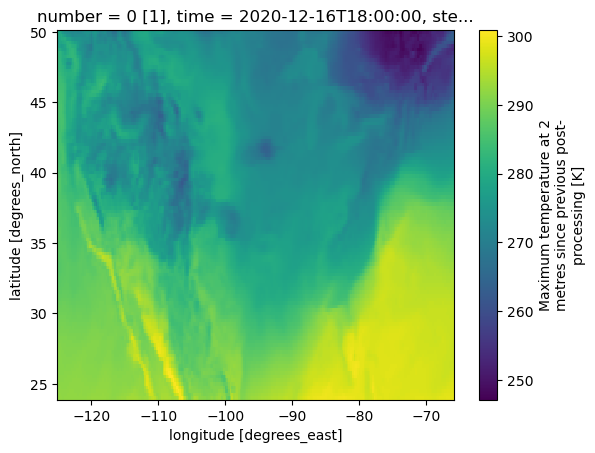

In [43]:
%matplotlib inline
weather[0].sel(time ='2020-12-16T18:00:00', step = '04:00:00')['mx2t'].plot()

In [28]:
msno.matrix(weather[0], labels=True)
plt.show()

AttributeError: 'Dataset' object has no attribute 'shape'

In [24]:
pd_weat = weather[0].to_dataframe()

In [25]:
pd_weat

number  surface  \
time                step            latitude longitude                    
2020-11-30 18:00:00 0 days 01:00:00 50.0     -125.00         0      0.0   
                                             -124.75         0      0.0   
                                             -124.50         0      0.0   
                                             -124.25         0      0.0   
                                             -124.00         0      0.0   
...                                                        ...      ...   
2020-12-31 18:00:00 0 days 12:00:00 24.0     -67.00          0      0.0   
                                             -66.75          0      0.0   
                                             -66.50          0      0.0   
                                             -66.25          0      0.0   
                                             -66.00          0      0.0   

                                                                valid_time  \
time                step            latitude longitude                       
2020-11-30 18:00:00 0 days 01:00:00 50.0     -125.00   2020-11-30 19:00:00   
                                             -124.75   2020-11-30 19:00:00   
                                             -124.50   2020-11-30 19:00:00   
                                             -124.25   2020-11-30 19:00:00   
                                             -124.00   2020-11-30 19:00:00   
...                                                                    ...   
2020-12-31 18:00:00 0 days 12:00:00 24.0     -67.00    2021-01-01 06:00:00   
                                             -66.75    2021-01-01 06:00:00   
                                             -66.50    2021-01-01 06:00:00   
                                             -66.25    2021-01-01 06:00:00   
                                             -66.00    2021-01-01 06:00:00   

                                                        fg10  mx2t  mn2t  tp  \
time                step            latitude longitude                         
2020-11-30 18:00:00 0 days 01:00:00 50.0     -125.00     NaN   NaN   NaN NaN   
                                             -124.75     NaN   NaN   NaN NaN   
                                             -124.50     NaN   NaN   NaN NaN   
                                             -124.25     NaN   NaN   NaN NaN   
                                             -124.00     NaN   NaN   NaN NaN   
...                                                      ...   ...   ...  ..   
2020-12-31 18:00:00 0 days 12:00:00 24.0     -67.00      NaN   NaN   NaN NaN   
                                             -66.75      NaN   NaN   NaN NaN   
                                             -66.50      NaN   NaN   NaN NaN   
                                             -66.25      NaN   NaN   NaN NaN   
                                             -66.00      NaN   NaN   NaN NaN   

                                                        mxtpr  
time                step            latitude longitude         
2020-11-30 18:00:00 0 days 01:00:00 50.0     -125.00      NaN  
                                             -124.75      NaN  
                                             -124.50      NaN  
                                             -124.25      NaN  
                                             -124.00      NaN  
...                                                       ...  
2020-12-31 18:00:00 0 days 12:00:00 24.0     -67.00       NaN  
                                             -66.75       NaN  
                                             -66.50       NaN  
                                             -66.25       NaN  
                                             -66.00       NaN  

[18813060 rows x 8 columns]

In [4]:
def hour_step(year, month, day, time):
    baseline = ''
    whole_hour = 0
    hour_int = 0
    step = 0
    hour_int = 0
    today = date(year, month, day)
    if (time/100) % 1 < 0.3:
        hour_int = int(time/100)
    else: hour_int = int(time/100) + 1
    if hour_int < 10:
        whole_hour = str(today) + 'T0' + str(hour_int) + ':00:00'
    elif hour_int == 24 :
        if today.year == (today + timedelta(days=1)).year:
            whole_hour = str(today + timedelta(days=1)) + 'T00:00:00'
        else: whole_hour = str(today) + 'T23:00:00'
    else: whole_hour = str(today) + 'T' + str(hour_int) + ':00:00'
    if 6 < hour_int and hour_int <= 18:
        baseline = 'T06:00:00'
        if hour_int - 6 < 10:
            step = '0' + str(hour_int - 6) + ':00:00'
        else: step = str(hour_int - 6) + ':00:00'
    elif hour_int > 18:
        baseline = 'T18:00:00'
        step = '0' + str(hour_int - 18) + ':00:00'
    elif hour_int <= 6:
        baseline = 'T18:00:00'
        if hour_int + 6 < 10:
            step = '0' + str(hour_int + 6) + ':00:00'
        else: step = str(hour_int + 6) + ':00:00'
        today = today - timedelta(days=1)
    hour = str(today) + baseline 
    return [hour, step, whole_hour]

In [5]:
def lon_lat(airport):
    lon_raw = iata_airports[airport]['lon']
    lat_raw = iata_airports[airport]['lat']
    lon = round(lon_raw * 4)/4
    lat = round(lat_raw * 4)/4
    return [lon, lat]

In [6]:
def weather_data(year, month, day, time, airport):
    hour, step, whole_hour = hour_step(year, month, day, time)
    lon, lat = lon_lat(airport)
    mx2t = weather[0]['mx2t'].sel(time = hour, step = step, latitude = lat, longitude = lon).item()
    mn2t = weather[0]['mn2t'].sel(time = hour, step = step, latitude = lat, longitude = lon).item()
    tp = weather[0]['tp'].sel(time = hour, step = step, latitude = lat, longitude = lon).item()
    mxtpr = weather[0]['mxtpr'].sel(time = hour, step = step, latitude = lat, longitude = lon).item()
    fg10 = weather[0]['fg10'].sel(time = hour, step = step, latitude = lat, longitude = lon).item()
    u10 = weather[1]['u10'].sel(time = whole_hour, latitude = lat, longitude = lon).item()
    v10 = weather[1]['v10'].sel(time = whole_hour, latitude = lat, longitude = lon).item()
    return [mx2t, mn2t, tp, mxtpr, fg10, u10, v10]